# Propeller sweep

The 5230SL and its propeller against Hobbywing's stand. No board.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

`coaxial.motor` holds the Hobbywing Platinum 5230SL 190KV as the manufacturer's sheet gives it - poles and friction from the sheet, R, Ld, Lq and J estimated from the size class - and the APC20x10E fitted over the sheet's own 22-row thrust stand at 37 V.

In [2]:
from coaxial.motor import PLATINUM_5230SL, APC20x10E, APC20X10E_CURVE, RATINGS, KT_NM_PER_AMP

print(PLATINUM_5230SL)
print(PLATINUM_5230SL.source)
print(APC20x10E, '-', APC20x10E.source)
print({k: RATINGS[k] for k in ('slots_poles', 'kv', 'i_max', 'p_max', 'source')})
print('Kt %.4f N.m/A' % KT_NM_PER_AMP)

<Hobbywing Platinum 5230SL 190KV ESTIMATED: R 0.0300 ohm, Ld 22.0 uH, Lq 29.0 uH, lambda 0.00207 Wb, 14 pole pairs, KV 190>
poles and friction from the manufacturer sheet (see RATINGS); R, Ld, Lq and J estimated from the size class - replace with an identification against the real machine
<APC20x10E: 5.143e-06 N.m/(rad/s)^2> - least squares over the 190KV sheet, 37 V, 25 C, sea level
{'slots_poles': '24N28P', 'kv': 190.0, 'i_max': 112.5, 'p_max': 4985.0, 'source': 'hobbywing.com Platinum 5220/5230 specification page'}
Kt 0.0435 N.m/A


The chain: a raised cosine to 6717 rpm and back, a speed loop, a current loop, the machine behind the propeller, at the stand's 37 V.

In [3]:
import math
from coaxial.loop import Ramp, SpeedLoop, CurrentLoop, Machine
from coaxial import inverter

TWO_PI = 2.0 * math.pi
motor = PLATINUM_5230SL
top = 6717.0 * TWO_PI / 60.0
chain = (Ramp(top, rise=2.0)
         >> SpeedLoop(hz=4.0, limit=RATINGS['i_max'], motor=motor, load=APC20x10E)
         >> CurrentLoop(hz=800.0, motor=motor, vdc=37.0)
         >> Machine(motor, vdc=37.0, load=APC20x10E, noise=0.0, sub=4))
dt = 4.0 * inverter.TS
run = chain.run(seconds=4.5, dt=dt, every=25)
rpm = run['w'] * 60.0 / TWO_PI
print('reached %.0f rpm, iq peak %.1f A, v_sat %.0f %% of the run'
      % (rpm.max(), abs(run['iq']).max(), 100.0 * run['v_sat'].mean()))

reached 5696 rpm, iq peak 46.5 A, v_sat 22 % of the run


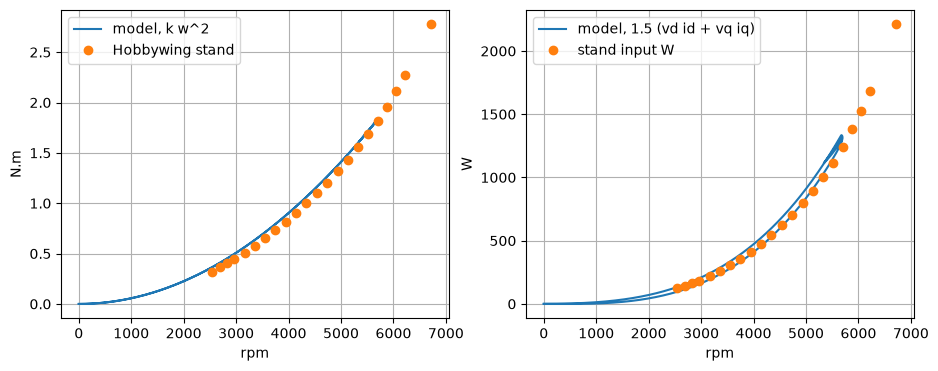

In [4]:
import numpy as np
import matplotlib.pyplot as plt

torque = APC20x10E.k * run['w'] ** 2
electrical = 1.5 * (run['vd'] * run['id'] + run['vq'] * run['iq'])
stand = np.array(APC20X10E_CURVE)
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))
a.plot(rpm, torque, label='model, k w^2')
a.plot(stand[:, 0], stand[:, 1], 'o', label='Hobbywing stand')
a.set_xlabel('rpm'); a.set_ylabel('N.m'); a.legend(); a.grid(True)
b.plot(rpm, electrical, label='model, 1.5 (vd id + vq iq)')
b.plot(stand[:, 0], stand[:, 2], 'o', label='stand input W')
b.set_xlabel('rpm'); b.set_ylabel('W'); b.legend(); b.grid(True)
plt.show()

In [5]:
print(' rpm    stand N.m   model N.m   stand W   model W')
for row_rpm, row_torque, row_watts in APC20X10E_CURVE[::4]:
    w = row_rpm * TWO_PI / 60.0
    near = np.argmin(np.abs(rpm - row_rpm))
    print('%5d   %8.2f   %8.2f   %8.0f   %8.0f'
          % (row_rpm, row_torque, APC20x10E.k * w * w, row_watts, electrical[near]))

 rpm    stand N.m   model N.m   stand W   model W
 2534       0.32       0.36        125        131
 3163       0.51       0.56        219        193
 3946       0.81       0.88        411        391
 4740       1.20       1.27        704        704
 5518       1.69       1.72       1118       1198
 6226       2.27       2.19       1684       1317


## Conclusions

In [6]:
worst = 0.0
for row_rpm, row_torque, _watts in APC20X10E_CURVE:
    w = row_rpm * TWO_PI / 60.0
    worst = max(worst, abs(APC20x10E.k * w * w / row_torque - 1.0))
print('propeller fit    k %.3e N.m/(rad/s)^2, worst point %.1f %% off a pure square'
      % (APC20x10E.k, 100.0 * worst))
top_row = APC20X10E_CURVE[-1]
iq_at_top = top_row[1] / KT_NM_PER_AMP
print('at %d rpm         %.2f N.m needs %.1f A of q current at Kt %.4f'
      % (top_row[0], top_row[1], iq_at_top, KT_NM_PER_AMP))
print('the board         %.0f A rated; the motor %.1f A burst'
      % (100.0, RATINGS['i_max']))
print('lambda            %.5f Wb from %d KV at %d pole pairs'
      % (motor.lam, RATINGS['kv'], motor.poles))
print('Kt = 1.5 P lambda %.4f N.m/A' % (1.5 * motor.poles * motor.lam))

propeller fit    k 5.143e-06 N.m/(rad/s)^2, worst point 13.2 % off a pure square
at 6717 rpm         2.78 N.m needs 63.9 A of q current at Kt 0.0435
the board         100 A rated; the motor 112.5 A burst
lambda            0.00207 Wb from 190 KV at 14 pole pairs
Kt = 1.5 P lambda 0.0435 N.m/A


The sheet pins the **product** `Kt = 1.5 P lambda`, not the pole count: lambda from a KV goes as 1/P, so the P cancels and iq is the same whether the machine has 5 pole pairs or 14. No torque measurement gives P; it came from the winding, 24N28P being 28 poles and 14 pairs, and the observer needs it on its own because electrical speed is P times mechanical.

`b` is arithmetic off the sheet: 3.0 A at 44.4 V spins it at 8436 rpm, so 133 W against 883 rad/s is 0.151 N.m of drag. R, Ld, Lq and J come from the size class; `auto_tune.ipynb` replaces them.

Two ratings bound the drive: the motor's 112.5 A burst sits above the board's 100 A, so the **inverter** is the limit, and a 12S pack at full charge is 50.4 V against a 63 V rating and 78.15 V of divider scale.

The model meets the stand at the stand's rpm because `k` was fitted over those 22 rows; the curve is kept whole in `APC20X10E_CURVE` so the fit can be re-done.